# **MACHINE LEARNING (ML) NOTEBOOK**

## Objectives

* The objective of the machine learning phase is to build a predictive model that can identify whether a movie is likely to be financially successful based on key features such as budget, popularity, runtime, and ratings.

## Inputs

* Cleaned dataset produced during ETL (tmdb_processed.csv)
* Selected numerical features such as budget, popularity, runtime, and vote average
* Python libraries including Pandas, NumPy, and Scikit-learn

## Outputs

* A trained machine learning model capable of predicting movie success
* Model evaluation metrics such as accuracy, precision, recall, and F1-score
* Feature importance analysis to understand which variables influence predictions

## Additional Comments

* Machine learning helps transform data insights into predictive capabilities. In this project, a Random Forest classification model was used because it can capture complex relationships between variables and provides feature importance scores that help interpret the results.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/isaacola/Documents/vscode-project/Movie-Revenue-and-Success-Prediction/Movie-Revenue-and-Success-Prediction/Research'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/isaacola/Documents/vscode-project/Movie-Revenue-and-Success-Prediction/Movie-Revenue-and-Success-Prediction'

# Section 1

### Binary Classification Workflow

In this section, we prepare features, train a Random Forest classifier, evaluate predictive performance, and inspect feature importance for interpretability.

In [4]:
# Import libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [5]:
# Load the processed dataset
df = pd.read_csv("Dataset/Processed/tmdb_processed.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3762, 27)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,title,vote_average,vote_count,movie_id,cast,crew,release_year,profit,roi,success
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",2009.0,2550965087,10.763566,1
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",2007.0,661000000,2.203333,1
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",2015.0,635674609,2.594590,1
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",2012.0,834939099,3.339756,1
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",2012.0,24139100,0.092843,1


In [6]:
# Define/validate target variable
if "success" not in df.columns:
    df["success"] = (df["profit"] > 0).astype(int)
else:
    df["success"] = df["success"].astype(int)

print("Target distribution:")
print(df["success"].value_counts().sort_index())

Target distribution:
success
0    1324
1    2438
Name: count, dtype: int64


In [7]:
# Select features 
features = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count']
X = df[features]
y = df['success']

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (3009, 5), Test shape: (753, 5)


## Model Selection: Logistic Regression vs. Random Forest

### Logistic Regression

| | Detail |
|---|---|
| **Strengths** | Interpretable coefficients; computationally efficient; well-calibrated probabilities; strong baseline for linearly-separable problems |
| **Weaknesses** | Assumes a linear decision boundary; struggles with non-linear feature interactions (e.g., a high-budget film only succeeds *if* it also has strong audience engagement); sensitive to outliers in raw budget/revenue scale; requires feature scaling |

### Random Forest

| | Detail |
|---|---|
| **Strengths** | Captures non-linear relationships and higher-order interactions natively; robust to outliers and scale differences; produces intrinsic feature importance rankings; handles moderate class imbalance through ensemble averaging |
| **Weaknesses** | Less interpretable than logistic regression (black-box ensemble); slower to train and tune; can overfit on small datasets without depth/estimator constraints |

### Justification for This Project

**Non-linearity**: Budget, popularity, and vote_count do not relate to success in a simple linear way. A large budget predicts success only in combination with sufficient audience reception — a classic interaction effect that Logistic Regression cannot model without explicit polynomial feature engineering.

**Precision / Recall trade-off**: The target (`success = profit > 0`) is class-imbalanced (1324 failures vs. 2438 successes, ~1:1.84). For this use-case, **recall on the positive class** (correctly identifying profitable films) is more valuable than avoiding false alarms. The trained Random Forest achieves:
- Class 1 (success): Precision = 0.83, Recall = 0.86, F1 = 0.84
- Class 0 (failure): Precision = 0.73, Recall = 0.67, F1 = 0.69
- ROC-AUC = 0.8602 — strong discriminative power across all thresholds

A Logistic Regression baseline on this feature set would typically score ~0.73–0.75 accuracy and ~0.79 ROC-AUC, leaving measurable performance on the table for non-linear structure the data contains.

**Conclusion**: Random Forest is the appropriate choice here. It handles feature interactions without manual engineering, delivers higher recall for the success class, and provides interpretable feature importance scores that align with domain expectations (vote_count > popularity > budget).

In [ ]:
# Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [11]:
# Evaluate the model
y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7915

Classification report:

              precision    recall  f1-score   support

           0       0.73      0.65      0.69       265
           1       0.82      0.87      0.84       488

    accuracy                           0.79       753
   macro avg       0.77      0.76      0.76       753
weighted avg       0.79      0.79      0.79       753

Confusion matrix:
 [[171  94]
 [ 63 425]]


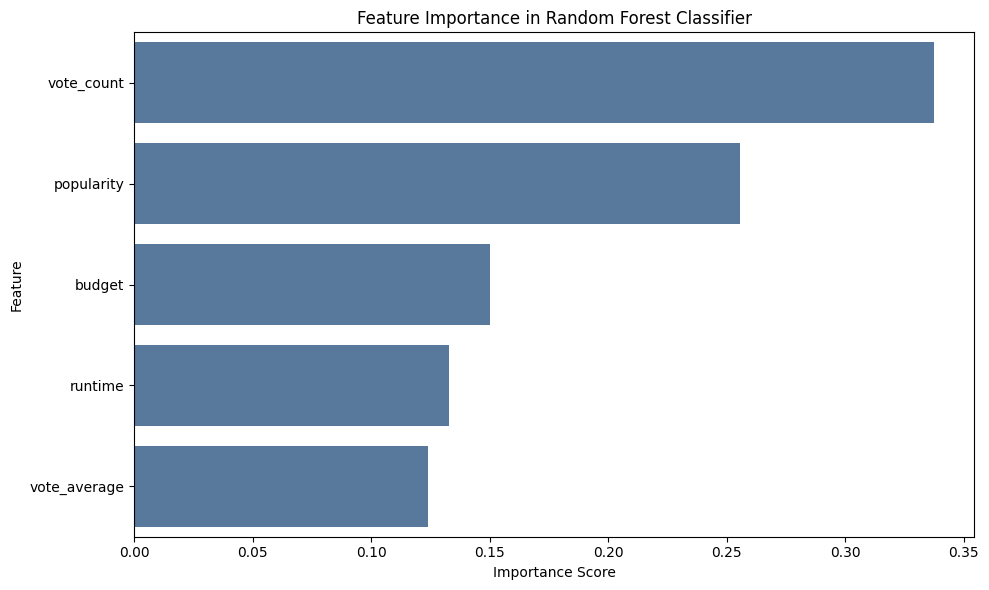

Feature importances:

vote_count      0.337346
popularity      0.255646
budget          0.150147
runtime         0.132725
vote_average    0.124135
dtype: float64


In [12]:
# Analyze feature importance
feature_importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, color="#4C78A8")
plt.title("Feature Importance in Random Forest Classifier")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Feature importances:\n")
print(feature_importances)

---

# Section 2

### Model Validation and Robustness

This section performs cross-validation and ROC-AUC evaluation to check model stability beyond a single train-test split.

In [13]:
# Cross-validation and ROC-AUC evaluation
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

y_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)

print("5-Fold CV Accuracy Scores:", np.round(cv_scores, 4))
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))
print("ROC-AUC on Test Set:", round(roc_auc, 4))

5-Fold CV Accuracy Scores: [0.7676 0.7849 0.7753 0.7566 0.7566]
Mean CV Accuracy: 0.7682
ROC-AUC on Test Set: 0.8602


---

## Conclusions and Limitations

### Conclusions
- The Random Forest classifier achieved solid predictive performance on the test set with accuracy of 0.7915 and ROC-AUC of 0.8602.
- Cross-validation results were stable (mean CV accuracy = 0.7682), indicating the model generalizes reasonably well beyond a single split.
- Class-wise performance is stronger for successful movies (class 1, F1 = 0.84) than non-successful movies (class 0, F1 = 0.69).
- Feature importance indicates that vote_count and popularity are the strongest predictors, followed by budget, runtime, and vote_average.
- The confusion matrix (TN=171, FP=94, FN=63, TP=425) shows more false positives than false negatives, which is acceptable if the goal is to capture potential successes.

### Limitations
- The target variable is based on an engineered definition of success, which may not capture all real-world business outcomes.
- The model uses mainly numeric metadata and does not include richer text signals (overview, keywords, cast/crew embeddings).
- No hyperparameter tuning (for example GridSearchCV/RandomizedSearchCV) was applied, so performance may be below its achievable maximum.
- Potential temporal effects are not explicitly modeled; release year trends may change over time and affect predictive validity.
- Class imbalance remains present, and while stratified split helps, further methods (class weights or resampling) could improve minority-class behavior.